<a href="https://colab.research.google.com/github/BALJITrs7/GNN-IDS/blob/main/FlowGraphv2_GATv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch-geometric -q

In [2]:
pip install pandas numpy scikit-learn matplotlib seaborn networkx tqdm

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import subprocess
import sys

def install_local_pyg_dependencies():
    torch_version = torch.__version__.split('+')[0]
    cuda_version = torch.version.cuda

    if cuda_version is None:
        cuda_str = "cpu"
    else:
        cuda_str = "cu" + cuda_version.replace(".", "")

    wheel_url = f"https://data.pyg.org/whl/torch-{torch_version}+{cuda_str}.html"
    print(f"Detected Local PyTorch: {torch_version} | CUDA: {cuda_version}")
    print(f"Fetching Windows wheels from: {wheel_url}\n")

    # On Windows, torch_sparse is highly recommended over pyg_lib
    packages = ["torch_scatter", "torch_sparse"]

    for pkg in packages:
        print(f"Installing {pkg}...")
        try:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", pkg, "-f", wheel_url]
            )
            print(f"Successfully installed {pkg}\n")
        except subprocess.CalledProcessError as e:
            print(f"Failed to install {pkg}. Error: {e}")

install_local_pyg_dependencies()

Detected Local PyTorch: 2.11.0 | CUDA: 12.8
Fetching Windows wheels from: https://data.pyg.org/whl/torch-2.11.0+cu128.html

Installing torch_scatter...

Installing torch_sparse...



In [4]:
import os

import pandas as pd
import numpy as np

import torch

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from torch_geometric.data import Data

In [5]:
DATASET_DIR = "/Users/balji/OneDrive/GNN_IDS/Balanced_6Class_400K"

files = {
    "BENIGN.csv":0,
    "DDoS.csv":1,
    "DoS.csv":1,
    "Mirai.csv":1,
    "Recon.csv":1,
    "Spoofing.csv":1
}

dfs = []

for file,label in files.items():

    path = os.path.join(DATASET_DIR,file)

    df = pd.read_csv(path)

    df["label"] = label

    dfs.append(df)

data = pd.concat(
    dfs,
    ignore_index=True
)

print(data.shape)

(400000, 87)


In [6]:
data = data.sort_values(
    "bidirectional_first_seen_ms"
).reset_index(drop=True)

data["flow_id"] = np.arange(len(data))

print(data.shape)

(400000, 88)


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import numpy as np
import pandas as pd

# 1. Save the keys needed for edge construction BEFORE extracting features
edge_keys = data[['src_mac', 'dst_ip', 'dst_port','bidirectional_first_seen_ms']].copy()
edge_keys['node_id'] = np.arange(len(data))

# 2. Explicitly define the TOP features from XGBoost
# We EXCLUDE ip_version, protocol, and dst_port to prevent memorization/leakage
XGBOOST_TOP_FEATURES = [
"bidirectional_duration_ms",
"bidirectional_packets",
"bidirectional_bytes",
"src2dst_duration_ms",
"src2dst_packets",
"src2dst_bytes",
"dst2src_duration_ms",
"dst2src_packets",
"dst2src_bytes",
"bidirectional_min_ps",
"bidirectional_mean_ps",
"bidirectional_stddev_ps",
"bidirectional_max_ps",
"src2dst_min_ps",
"src2dst_mean_ps",
"src2dst_stddev_ps",
"src2dst_max_ps",
"dst2src_min_ps",
"dst2src_mean_ps",
"dst2src_stddev_ps",
"dst2src_max_ps",
"bidirectional_min_piat_ms",
"bidirectional_mean_piat_ms",
"bidirectional_stddev_piat_ms",
"bidirectional_max_piat_ms",
"src2dst_min_piat_ms",
"src2dst_mean_piat_ms",
"src2dst_stddev_piat_ms",
"src2dst_max_piat_ms",
"dst2src_min_piat_ms",
"dst2src_mean_piat_ms",
"dst2src_stddev_piat_ms",
"dst2src_max_piat_ms",
"bidirectional_syn_packets",
"bidirectional_cwr_packets",
"bidirectional_ece_packets",
"bidirectional_urg_packets",
"bidirectional_ack_packets",
"bidirectional_psh_packets",
"bidirectional_rst_packets",
"bidirectional_fin_packets",
"src2dst_syn_packets",
"src2dst_cwr_packets",
"src2dst_ece_packets",
"src2dst_urg_packets",
"src2dst_ack_packets",
"src2dst_psh_packets",
"src2dst_rst_packets",
"src2dst_fin_packets",
"dst2src_syn_packets",
"dst2src_cwr_packets",
"dst2src_ece_packets",
"dst2src_urg_packets",
"dst2src_ack_packets",
"dst2src_psh_packets",
"dst2src_rst_packets",
"dst2src_fin_packets"

]

print(f"Using {len(XGBOOST_TOP_FEATURES)} pure statistical features.")

# Convert to numeric and fill NaNs
for col in XGBOOST_TOP_FEATURES:
    data[col] = pd.to_numeric(data[col], errors="coerce")
data[XGBOOST_TOP_FEATURES] = data[XGBOOST_TOP_FEATURES].fillna(0)

# 3. Transductive Split & Isolated Scaling
labels = data["label"].values
idx = np.arange(len(data))

# Split indices first
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=labels)

# Extract only the chosen 27 features
X_raw = data[XGBOOST_TOP_FEATURES].values
scaler = StandardScaler()

# Fit the scaler ONLY on the training data to prevent future-peeking
scaler.fit(X_raw[train_idx])

# Transform all data using the train-derived mean and variance
X_scaled = scaler.transform(X_raw)

# Convert to tensors
X = torch.tensor(X_scaled, dtype=torch.float)
y = torch.tensor(labels, dtype=torch.long)

print(f"X Tensor Shape: {X.shape}") # Should now be [400000, 27]

Using 57 pure statistical features.
X Tensor Shape: torch.Size([400000, 57])


In [8]:
from tqdm import tqdm

print("Grouping nodes by Destination IP, Port, and Protocol...")
# Group the dataset by our target profile
grouped = edge_keys.groupby(['src_mac','dst_port', 'dst_ip'])

source_nodes = []
target_nodes = []

print("Executing Temporal Sliding Window (2-second limit)...")
for _, group in tqdm(grouped, desc="Building Temporal Edges"):
    # Ensure the group is sorted by time
    group = group.sort_values('bidirectional_first_seen_ms')

    times = group['bidirectional_first_seen_ms'].values
    nodes = group['node_id'].values
    n = len(times)

    # Optimized two-pointer sliding window
    for i in range(n):
        j = i + 1
        # Look ahead: If the next flow is within 2000 ms, draw an edge
        while j < n and (times[j] - times[i]) <= 2000:
            # Undirected graph requires both directions
            source_nodes.extend([nodes[i], nodes[j]])
            target_nodes.extend([nodes[j], nodes[i]])
            j += 1

# Compile the final edge matrix
edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)
print(f"\nFinal Temporal edge_index shape: {edge_index.shape}")

Grouping nodes by Destination IP, Port, and Protocol...
Executing Temporal Sliding Window (2-second limit)...


Building Temporal Edges: 100%|██████████| 62434/62434 [00:51<00:00, 1216.80it/s]



Final Temporal edge_index shape: torch.Size([2, 61645086])


In [9]:
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader

# 1. Create Boolean Masks
num_nodes = len(data)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

# 2. Instantiate the pure Flow-to-Flow Graph
graph = Data(x=X, edge_index=edge_index, y=y, train_mask=train_mask, test_mask=test_mask)
print("\nFinal Homogeneous Graph Structure:")
print(graph)

# 3. HIGH-PERFORMANCE DATA LOADERS
print("Initializing Multi-Threaded Loaders...")

train_loader = NeighborLoader(
    graph,
    num_neighbors=[25, 15],
    batch_size=2048,
    input_nodes=graph.train_mask,
    shuffle=True,
    num_workers=2,           # Utilizing multiple CPU cores
    #pin_memory=True,         # Fast PCIe data transfer
    #persistent_workers=True  # Prevents Windows worker-spawn crashes
)

test_loader = NeighborLoader(
    graph,
    num_neighbors=[25, 15],
    batch_size=2048,
    input_nodes=graph.test_mask,
    shuffle=False,
    num_workers=2,
    #pin_memory=True,
    #persistent_workers=True
)

print(f"Subgraphs to process per epoch: {len(train_loader)}")


Final Homogeneous Graph Structure:
Data(x=[400000, 57], edge_index=[2, 61645086], y=[400000], train_mask=[400000], test_mask=[400000])
Initializing Multi-Threaded Loaders...
Subgraphs to process per epoch: 157


In [10]:
#GAT Model

import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv

class GATModel(torch.nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels,
        num_classes,
        heads=4
    ):

        super().__init__()

        self.conv1 = GATv2Conv(
            in_channels,
            hidden_channels // heads,
            heads=heads
        )

        self.conv2 = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads
        )

        # Layer 3 targets an output of hidden_channels // 2 (128).
        self.conv3 = GATv2Conv(
            hidden_channels,
            (hidden_channels // 2) // heads,
            heads=heads
        )

        self.bn1 = torch.nn.BatchNorm1d(
            hidden_channels
        )

        self.bn2 = torch.nn.BatchNorm1d(
            hidden_channels
        )

        self.bn3 = torch.nn.BatchNorm1d(
            hidden_channels // 2
        )

        self.classifier = torch.nn.Linear(
            hidden_channels // 2,
            num_classes
        )

    def forward(
        self,
        x,
        edge_index
    ):

        x = self.conv1(
            x,
            edge_index
        )

        x = self.bn1(x)

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.4,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index
        )

        x = self.bn2(x)

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.4,
            training=self.training
        )

        x = self.conv3(
            x,
            edge_index
        )

        x = self.bn3(x)

        x = F.relu(x)

        x = self.classifier(x)

        return x


In [11]:

# 1. Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Initialize the model AND move it to the device
model = GATModel(
    in_channels=graph.num_node_features,
    hidden_channels=256,
    num_classes=2,
    heads=4
).to(device) # <--- THIS IS THE CRITICAL MISSING PIECE

# 3. Re-initialize the optimizer since the model parameters just moved to a new device
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.002,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=20,
    gamma=0.5
)

# 4. Move the loss function to the device
criterion = torch.nn.CrossEntropyLoss().to(device)

Using device: cuda


In [12]:
# Assuming model, optimizer, and criterion are initialized and moved to device
def train_epoch():
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        # Forward pass on the subgraph
        out = model(batch.x, batch.edge_index)

        # SLICE the output: Only calculate loss for the seed nodes in this batch
        loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * batch.batch_size

    return total_loss / graph.train_mask.sum().item()

@torch.no_grad()
def evaluate_epoch(loader):
    model.eval()
    correct = 0
    total = 0

    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)

        # Evaluate only the seed nodes
        pred = out[:batch.batch_size].argmax(dim=1)
        y_true = batch.y[:batch.batch_size]

        correct += (pred == y_true).sum().item()
        total += batch.batch_size

    return correct / total



In [13]:
# Training Execution
for epoch in range(1, 51):
    loss = train_epoch()
    train_acc = evaluate_epoch(train_loader)

    # We DO NOT evaluate test_acc during training to prevent leakage tweaking.
    # It is kept blind until epoch 50 finishes.
    scheduler.step()

    print(f"Epoch {epoch:02d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f}")

# Final Blind Test Evaluation
print("-" * 40)
final_test_acc = evaluate_epoch(test_loader)
print(f"FINAL BLIND TEST ACCURACY: {final_test_acc:.4f}")

#torch.save(model.state_dict(), 'FlowGraph_GATv2.pth')
#print("Model weights successfully saved to disk as 'gat_ids_model_100epochs.pth'")

Epoch 01 | Loss: 0.4590 | Train Acc: 0.8187
Epoch 02 | Loss: 0.3787 | Train Acc: 0.8357
Epoch 03 | Loss: 0.3467 | Train Acc: 0.8393
Epoch 04 | Loss: 0.3323 | Train Acc: 0.8463
Epoch 05 | Loss: 0.3241 | Train Acc: 0.8553
Epoch 06 | Loss: 0.3130 | Train Acc: 0.8604
Epoch 07 | Loss: 0.3046 | Train Acc: 0.8707
Epoch 08 | Loss: 0.3006 | Train Acc: 0.8726
Epoch 09 | Loss: 0.2958 | Train Acc: 0.8648
Epoch 10 | Loss: 0.2934 | Train Acc: 0.8784
Epoch 11 | Loss: 0.2880 | Train Acc: 0.8825
Epoch 12 | Loss: 0.2846 | Train Acc: 0.8814
Epoch 13 | Loss: 0.2812 | Train Acc: 0.8791
Epoch 14 | Loss: 0.2782 | Train Acc: 0.8825
Epoch 15 | Loss: 0.2757 | Train Acc: 0.8825
Epoch 16 | Loss: 0.2709 | Train Acc: 0.8869
Epoch 17 | Loss: 0.2706 | Train Acc: 0.8868
Epoch 18 | Loss: 0.2681 | Train Acc: 0.8869
Epoch 19 | Loss: 0.2644 | Train Acc: 0.8188
Epoch 20 | Loss: 0.2642 | Train Acc: 0.8876
Epoch 21 | Loss: 0.2537 | Train Acc: 0.8860
Epoch 22 | Loss: 0.2480 | Train Acc: 0.8924
Epoch 23 | Loss: 0.2482 | Train 

Exception ignored while calling deallocator <function _MultiProcessingDataLoaderIter.__del__ at 0x000002DCFEA29BC0>:
Traceback (most recent call last):
  File "C:\Users\balji\colab_env\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "C:\Users\balji\colab_env\Lib\site-packages\torch\utils\data\dataloader.py", line 1673, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "C:\Users\balji\AppData\Local\Python\pythoncore-3.14-64\Lib\multiprocessing\process.py", line 156, in join
    res = self._popen.wait(timeout)
  File "C:\Users\balji\AppData\Local\Python\pythoncore-3.14-64\Lib\multiprocessing\popen_spawn_win32.py", line 114, in wait
    res = _winapi.WaitForSingleObject(int(self._handle), msecs)
KeyboardInterrupt: 


KeyboardInterrupt: 

Gathering final predictions from the blind test set...

--- Final Test Classification Report ---
               precision    recall  f1-score   support

   Benign (0)     0.8507    0.9488    0.8971     40000
Malicious (1)     0.9422    0.8334    0.8845     40000

     accuracy                         0.8911     80000
    macro avg     0.8964    0.8911    0.8908     80000
 weighted avg     0.8964    0.8911    0.8908     80000



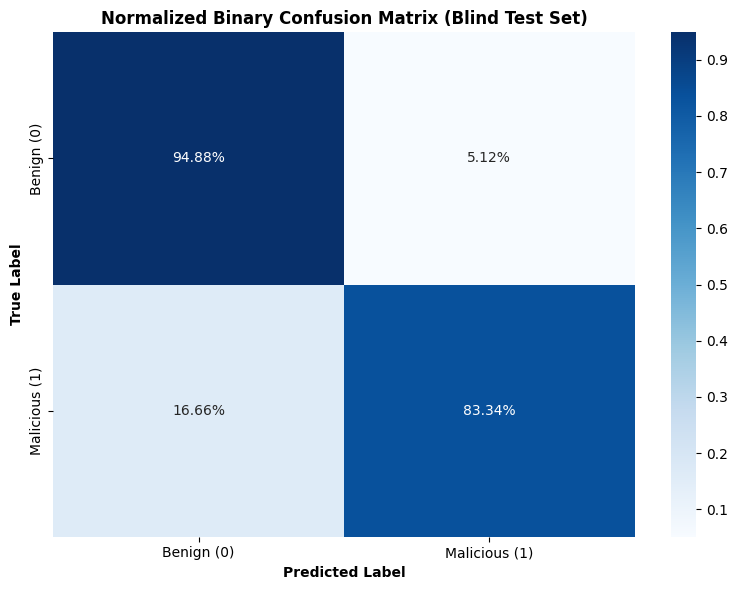

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Gathering final predictions from the blind test set...")

# 1. Extract Predictions and True Labels
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)

        # SLICE: Only evaluate the seed nodes to prevent overlapping evaluations
        pred = out[:batch.batch_size].argmax(dim=1)
        y_true = batch.y[:batch.batch_size]

        all_preds.extend(pred.cpu().numpy())
        all_true.extend(y_true.cpu().numpy())

# Convert to numpy arrays for Scikit-Learn
all_preds = np.array(all_preds)
all_true = np.array(all_true)

# 2. Print the Classification Report
target_names = ['Benign (0)', 'Malicious (1)']
print("\n--- Final Test Classification Report ---")
print(classification_report(all_true, all_preds, target_names=target_names, digits=4))

# 3. Calculate and Plot the Confusion Matrix
cm = confusion_matrix(all_true, all_preds)

# Normalize the matrix row-wise to get percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2%",
    cmap="Blues", # Changed to Blues for visual contrast
    xticklabels=target_names,
    yticklabels=target_names,
    cbar=True
)

plt.xlabel("Predicted Label", fontweight='bold')
plt.ylabel("True Label", fontweight='bold')
plt.title("Normalized Binary Confusion Matrix (Blind Test Set)", fontweight='bold')
plt.tight_layout()
plt.show()